In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Preparing the data

In [25]:
df = pd.read_csv("KNNAlgorithmDataset.csv")
df = df.drop(columns=["id"]).dropna(axis=1, how="all")


# Target: Diagnosis (M = Malignant, B = Benign)
# Encode: B = 0, M = 1
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"]) # B = 0, M = 1

print("Classes: ", le.classes_)
print("Encoded Classes: ", le.transform(le.classes_))
print("Shape: ", df.shape)
print(df[["diagnosis", "radius_mean", "texture_mean", "perimeter_mean"]].head())


Classes:  ['B' 'M']
Encoded Classes:  [0 1]
Shape:  (569, 31)
   diagnosis  radius_mean  texture_mean  perimeter_mean
0          1        17.99         10.38          122.80
1          1        20.57         17.77          132.90
2          1        19.69         21.25          130.00
3          1        11.42         20.38           77.58
4          1        20.29         14.34          135.10


### Binary KNN

In [26]:
X_bin = df[["radius_mean", "texture_mean"]].values
y_bin = df["diagnosis"].values

scaler = StandardScaler()
X_bin_scaled = scaler.fit_transform(X_bin)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin_scaled, y_bin, test_size=0.2, random_state=42)
best_k = max(range(1, 21), key=lambda k: KNeighborsClassifier(n_neighbors=k).fit(X_train_bin, y_train_bin).score(X_test_bin, y_test_bin))
print(f"Best k: {best_k}")

knn_bin = KNeighborsClassifier(n_neighbors=best_k)
knn_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = knn_bin.predict(X_test_bin)

print("Binary Classification Accuracy: ", knn_bin.score(X_test_bin, y_test_bin))

Best k: 10
Binary Classification Accuracy:  0.9298245614035088


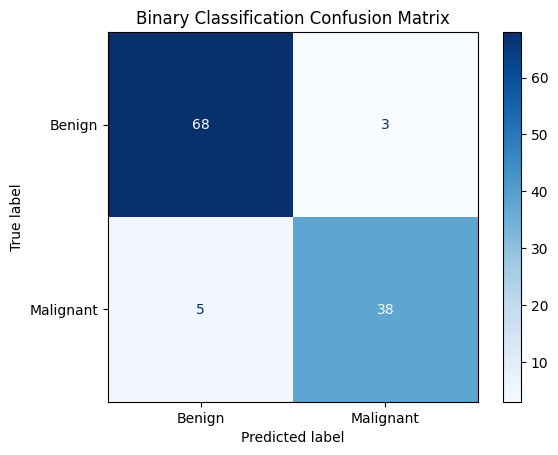

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin,
                              display_labels=["Benign", "Malignant"])

disp.plot(cmap="Blues")
plt.title("Binary Classification Confusion Matrix")
plt.show()

### Multiclass KNN

In [ ]:
df["target"] = df["diagnosis"].astype(str)
median_r = df.loc[df["diagnosis"] == 1, "radius_mean"].median()
df.loc[(df["diagnosis"] == 1) & (df["radius_mean"] <= median_r), "target"] = "M_small"
df.loc[(df["diagnosis"] == 1) & (df["radius_mean"] >  median_r), "target"] = "M_large"
df.loc[ df["diagnosis"] == 0, "target"] = "Benign"

X_mul = df.drop(columns=["diagnosis", "target"]).values
y_mul = df["target"].values

X_mul = StandardScaler().fit_transform(X_mul)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_mul, y_mul, test_size=0.2, random_state=42)
best_k = max(range(1, 21), key=lambda k: KNeighborsClassifier(n_neighbors=k).fit(Xm_tr, ym_tr).score(Xm_te, ym_te))  # ← multiclass data
print(f"Best k for multiclass: {best_k}")
knn_mul = KNeighborsClassifier(n_neighbors=best_k)  # ← actually uses best_k
knn_mul.fit(Xm_tr, ym_tr)
print(f"Multiclass accuracy: {knn_mul.score(Xm_te, ym_te):.2%}")
y_pred_mul = knn_mul.predict(Xm_te)

Best k for multiclass: 3
Multiclass accuracy: 92.11%


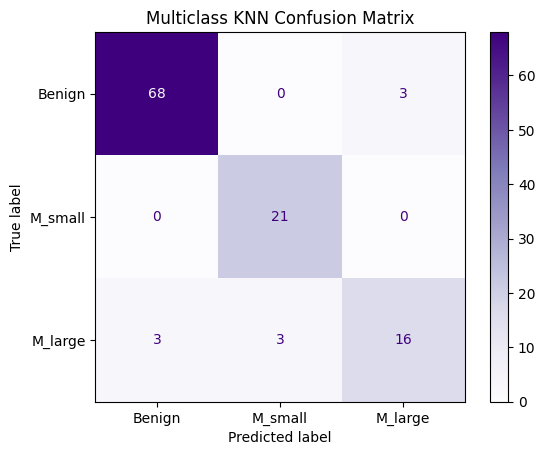

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ym_te, y_pred_mul)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign","M_small","M_large"]
)

disp.plot(cmap="Purples")
plt.title("Multiclass KNN Confusion Matrix")
plt.show()

### Boundary Line

### Visualisations

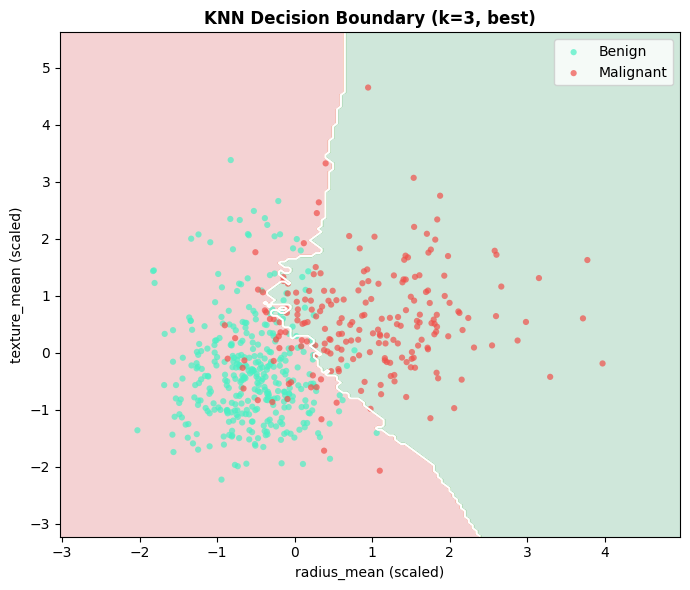

In [38]:

# Decision boundary
h = 0.05
xx, yy = np.meshgrid(np.arange(X_bin_scaled[:,0].min()-1, X_bin_scaled[:,0].max()+1, h),
                      np.arange(X_bin_scaled[:,1].min()-1, X_bin_scaled[:,1].max()+1, h))
Z = knn_bin.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.2, cmap="RdYlGn")
ax.contour(xx, yy, Z, levels=[0.5], colors="white", linewidths=1.5)  # boundary line

for label, color, name in [(0, "#4af0c4", "Benign"), (1, "#f0504a", "Malignant")]:
    mask = y_bin == label
    ax.scatter(X_bin_scaled[mask, 0], X_bin_scaled[mask, 1], c=color, label=name, s=20, alpha=0.7, edgecolors="none")

ax.set_title(f"KNN Decision Boundary (k={best_k}, best)", fontweight="bold")
ax.set_xlabel("radius_mean (scaled)")
ax.set_ylabel("texture_mean (scaled)")
ax.legend()
plt.tight_layout()
plt.savefig("knn_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

### Multiclass Prediction plot


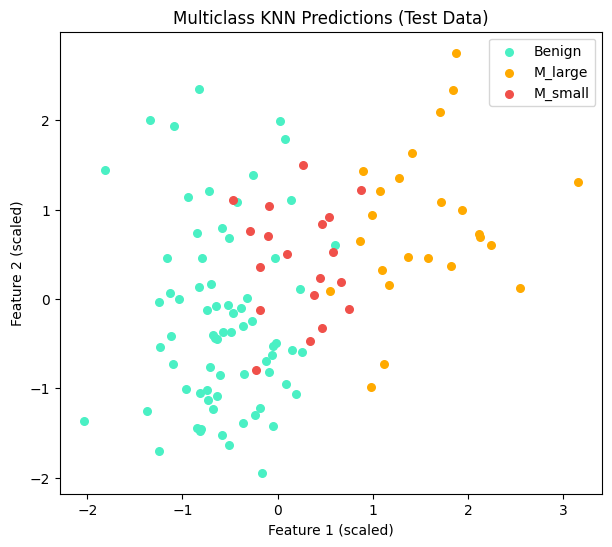

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# predictions from trained model
y_pred_mul = knn_mul.predict(Xm_te)

# encode labels for coloring
le = LabelEncoder()
y_pred_enc = le.fit_transform(y_pred_mul)

# use first two features for visualization
X_vis = Xm_te[:, :2]

plt.figure(figsize=(7,6))

colors = ["#4af0c4", "#ffaa00", "#f0504a"]

for i, label in enumerate(le.classes_):
    mask = y_pred_enc == i
    plt.scatter(
        X_vis[mask,0],
        X_vis[mask,1],
        c=colors[i],
        label=label,
        s=30
    )

plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("Multiclass KNN Predictions (Test Data)")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_bin, y_pred_bin))
y_pred_mul = knn_mul.predict(Xm_te)
print(classification_report(ym_te, y_pred_mul))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        71
           1       0.93      0.88      0.90        43

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        71
     M_large       0.88      1.00      0.93        21
     M_small       0.84      0.73      0.78        22

    accuracy                           0.92       114
   macro avg       0.89      0.90      0.89       114
weighted avg       0.92      0.92      0.92       114



In [43]:
from sklearn.metrics import accuracy_score

# Training accuracy
train_acc_bin = knn_bin.score(X_train_bin, y_train_bin)

# Test accuracy
test_acc_bin = knn_bin.score(X_test_bin, y_test_bin)

print("Binary KNN Accuracy")
print(f"Training Accuracy: {train_acc_bin:.4f}")
print(f"Test Accuracy: {test_acc_bin:.4f}")

Binary KNN Accuracy
Training Accuracy: 0.8945
Test Accuracy: 0.9298


In [44]:
# Training accuracy
train_acc_mul = knn_mul.score(Xm_tr, ym_tr)

# Test accuracy
test_acc_mul = knn_mul.score(Xm_te, ym_te)

print("\nMulticlass KNN Accuracy")
print(f"Training Accuracy: {train_acc_mul:.4f}")
print(f"Test Accuracy: {test_acc_mul:.4f}")


Multiclass KNN Accuracy
Training Accuracy: 0.9538
Test Accuracy: 0.9211
